In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import matplotlib.pyplot as plt

In [2]:
lstm_df = pd.read_csv(
    "../data/processed/lstm_forecast.csv"
)

lstm_df.head()

,Actual,Predicted
0,54198.37,23900.797
1,17240.61,28173.322
2,33393.29,26444.152
3,19808.40,27390.066
4,20277.05,26231.467


In [3]:
prophet_df = pd.read_csv(
    "../data/processed/sales_forecast.csv"
)

prophet_df.head()

,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,56388.633212,40938.080950,71852.147689
1,2009-12-02,53943.073819,38541.525653,70483.776354
2,2009-12-03,61071.679344,45166.886353,77673.725952
3,2009-12-04,51095.579199,35243.865377,67046.029075
4,2009-12-05,9529.931498,-7177.457581,26059.781353


In [4]:
prophet_recent = prophet_df.tail(
    len(lstm_df)
).reset_index(drop=True)

len(prophet_recent), len(lstm_df)

(115, 115)

In [5]:
hybrid_df = pd.DataFrame()

hybrid_df["Actual"] = lstm_df["Actual"]

hybrid_df["Prophet"] = prophet_recent["yhat"]

hybrid_df["LSTM"] = lstm_df["Predicted"]

hybrid_df["Hybrid"] = (
    hybrid_df["Prophet"] +
    hybrid_df["LSTM"]
) / 2

hybrid_df.head()

,Actual,Prophet,LSTM,Hybrid
0,54198.37,21058.781384,23900.797,22479.789192
1,17240.61,12084.583175,28173.322,20128.952588
2,33393.29,23969.076717,26444.152,25206.614358
3,19808.40,27247.402073,27390.066,27318.734037
4,20277.05,25271.675084,26231.467,25751.571042


In [6]:
actual = hybrid_df["Actual"]

prophet_mae = mean_absolute_error(
    actual,
    hybrid_df["Prophet"]
)

lstm_mae = mean_absolute_error(
    actual,
    hybrid_df["LSTM"]
)

hybrid_mae = mean_absolute_error(
    actual,
    hybrid_df["Hybrid"]
)

print("Prophet MAE :", prophet_mae)
print("LSTM MAE    :", lstm_mae)
print("Hybrid MAE  :", hybrid_mae)

Prophet MAE : 20253.372728056907
LSTM MAE    : 14078.198704347822
Hybrid MAE  : 16030.932314050342


In [7]:
prophet_rmse = np.sqrt(
    mean_squared_error(
        actual,
        hybrid_df["Prophet"]
    )
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual,
        hybrid_df["LSTM"]
    )
)

hybrid_rmse = np.sqrt(
    mean_squared_error(
        actual,
        hybrid_df["Hybrid"]
    )
)

print("Prophet RMSE :", prophet_rmse)
print("LSTM RMSE    :", lstm_rmse)
print("Hybrid RMSE  :", hybrid_rmse)

Prophet RMSE : 29449.465906647347
LSTM RMSE    : 21727.12027278423
Hybrid RMSE  : 23988.104200988288


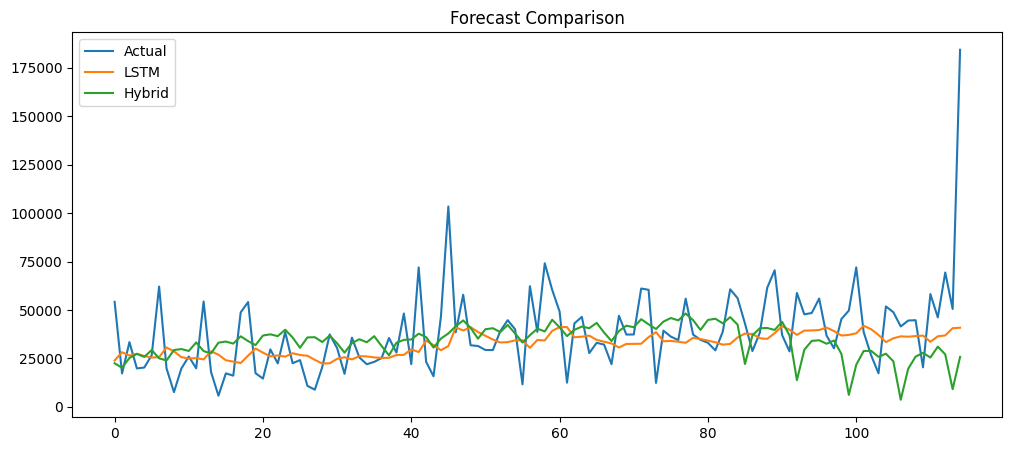

In [8]:
plt.figure(figsize=(12,5))

plt.plot(
    hybrid_df["Actual"].values,
    label="Actual"
)

plt.plot(
    hybrid_df["LSTM"].values,
    label="LSTM"
)

plt.plot(
    hybrid_df["Hybrid"].values,
    label="Hybrid"
)

plt.title("Forecast Comparison")
plt.legend()

plt.savefig(
    "../screenshots/hybrid_forecast.png"
)

plt.show()

In [9]:
hybrid_df.to_csv(
    "../data/processed/hybrid_forecast.csv",
    index=False
)

print("Hybrid forecast saved successfully!")

Hybrid forecast saved successfully!
